# Daily Occupancy Forecasting & Demand Dynamics Modeling  
#### Reconstructing Daily Occupancy Dynamics from Weekly Stay Records

###  Business Context

This project analyzes a real-world dataset from a medium-term accommodation business, where units are rented for stays longer than traditional short-term rentals (e.g., hostels or hotels).  

The main business objective is to:

- Understand and forecast **occupancy dynamics**
- Detect and anticipate **demand spikes and drops**
- Support **pricing, availability, and operational decisions**

Unlike hotels, demand in this context is strongly influenced by:
- booking timing behavior  
- cancellations (notices)  
- customer stay patterns  
- operational constraints (unit availability, gender-based allocation, etc.)

### Operational Logic of the Business

This business follows a continuous occupancy model:

- Customers remain in the system until notice is given
- Departures are not tied to fixed checkout cycles
- Occupancy evolves through inflows and outflows

This can be expressed as a **state-transition process**:   Occupancy_{t+1} = Occupancy_t + Bookings − Notices

Where:
- Occupancy_t is the current system state
- Bookings represent inflows (future occupancy increases)
- Notices represent outflows (future occupancy decreases)
- Timing delays depend on booking lead time and notice behavior

#### Why this matters

This forecasting problem is not purely a standard demand prediction task.  
It is more accurately framed as a **state evolution problem**, where changes in occupancy depend on the interaction between:

- current occupancy level
- incoming demand
- outgoing demand
- timing frictions between booking and departure behavior

#### Original Dataset Structure

The source dataset is built as a weekly tracking system, where:

- Each row represents:
- 1 Customer × 1 Unit × 1 Week
- A single stay is therefore split across multiple rows

##### Key limitation

This structure introduces important issues:

- Booking and notice events are repeated across weeks
- Temporal precision is limited to weekly granularity
- Demand spikes and short-term dynamics are smoothed or diluted

### Objective of Data Transformation

To address these limitations, the dataset is transformed into a daily representation, allowing:

- Accurate measurement of daily occupancy
- Proper counting of booking and notice events
- Reconstruction of true demand signals
- Better modeling of short-term dynamics and spikes

#### Key Variables

##### Stay Structure
- `Customer_ID`, `Unit_ID`
- `MoveIn_Date`, `MoveOut_Date`
- `Week`
- `Occupied_Days` (number of days occupied within that week)

##### Booking & Notice Behavior
- `Booking_Date`, `Booking_Time`
- `Notice_Date`, `Notice_Time`
- `Cancelled`

##### Customer & Stay Attributes
- `Age`, `Sex`
- `With_Agent`, `Type_Pref`
- `Stay_Length`, `PreArrival_CheckOut`

### 1. Load the dataset

The dataset is loaded and inspected to:

- confirm structure and columns
- identify duplicated stay records
- validate that each stay appears multiple times (weekly snapshots)

In [65]:
import pandas as pd
import numpy as np

df = pd.read_csv("daily_dataset_for_ML.csv")

print("Original dataset shape:", df.shape)

# Check columns
print(df.columns.tolist())

# Check duplicates
dup_check = df.duplicated(
    subset=["Customer_ID", "Unit_ID", "MoveIn_Date", "MoveOut_Date"]
).sum()

print("Duplicate stay rows:", dup_check)

Original dataset shape: (12985, 23)
['Customer_ID', 'MoveIn_Date', 'MoveOut_Date', 'Unit_ID', 'Unit_Occ_Length', 'Week', 'Occupied_Days', 'CheckIn_Date', 'Cancelled', 'Age', 'Sex', 'Booking_Date', 'Type_Pref', 'PreArrival_CheckOut', 'With_Agent', 'Notice_Date', 'Checkout_Date', 'Booking_Time', 'Notice_Time', 'Stay_Length', 'units_available', 'Booking_Date_Week', 'Notice_Date_Week']
Duplicate stay rows: 11133


### 2. Data cleaning and stay-level reconstruction

The original dataset is structured as weekly snapshots, where each stay appears multiple times.
To recover the true operational timeline, stays are first deduplicated using unique identifiers and validated for date consistency.

Each valid stay is then expanded into a daily sequence of records, transforming the data from a static weekly representation into a continuous time series. This enables accurate tracking of unit occupancy and preserves the temporal structure of customer stays.

#### 2.1 Deduplicate stays and standardize dates

In [66]:
# Keep one row per unique stay
df_stays = df.drop_duplicates(
    subset=["Customer_ID", "Unit_ID", "MoveIn_Date", "MoveOut_Date"]
).copy()

print("Original rows:", df.shape[0])
print("Unique stays:", df_stays.shape[0])

# Convert date fields
date_cols = [
    "MoveIn_Date",
    "MoveOut_Date",
    "Booking_Date",
    "Notice_Date",
    "CheckIn_Date",
    "Checkout_Date"
]

for col in date_cols:
    if col in df_stays.columns:
        df_stays[col] = pd.to_datetime(df_stays[col], dayfirst=True, errors="coerce")

print("\nMissing values after date conversion:")
print(df_stays[["MoveIn_Date", "MoveOut_Date", "Booking_Date", "Notice_Date"]].isna().sum())

bad_dates = df_stays[
    df_stays["MoveIn_Date"].isna() |
    df_stays["MoveOut_Date"].isna()
].copy()

print("\nRows with invalid move-in / move-out dates:", bad_dates.shape[0])
print(bad_dates.head(10))

Original rows: 12985
Unique stays: 1852

Missing values after date conversion:
MoveIn_Date       0
MoveOut_Date      0
Booking_Date      4
Notice_Date     125
dtype: int64

Rows with invalid move-in / move-out dates: 0
Empty DataFrame
Columns: [Customer_ID, MoveIn_Date, MoveOut_Date, Unit_ID, Unit_Occ_Length, Week, Occupied_Days, CheckIn_Date, Cancelled, Age, Sex, Booking_Date, Type_Pref, PreArrival_CheckOut, With_Agent, Notice_Date, Checkout_Date, Booking_Time, Notice_Time, Stay_Length, units_available, Booking_Date_Week, Notice_Date_Week]
Index: []

[0 rows x 23 columns]


#### 2.2 Remove invalid stay intervals

In [67]:
# Check for failed parses
invalid_ranges = df_stays[
    df_stays["MoveOut_Date"] <= df_stays["MoveIn_Date"]
].copy()

print("Invalid or zero-length stays:", invalid_ranges.shape[0])
print(invalid_ranges.head())

df_stays = df_stays[
    df_stays["MoveOut_Date"] > df_stays["MoveIn_Date"]
].copy()

Invalid or zero-length stays: 0
Empty DataFrame
Columns: [Customer_ID, MoveIn_Date, MoveOut_Date, Unit_ID, Unit_Occ_Length, Week, Occupied_Days, CheckIn_Date, Cancelled, Age, Sex, Booking_Date, Type_Pref, PreArrival_CheckOut, With_Agent, Notice_Date, Checkout_Date, Booking_Time, Notice_Time, Stay_Length, units_available, Booking_Date_Week, Notice_Date_Week]
Index: []

[0 rows x 23 columns]


#### 2.3 Expand stays to daily rows

In [68]:
# Expand to daily rows
expanded_rows = []

for _, row in df_stays.iterrows():
    date_range = pd.date_range(
        start=row["MoveIn_Date"],
        end=row["MoveOut_Date"] - pd.Timedelta(days=1),
        freq="D"
    )

    for current_date in date_range:
        expanded_rows.append({
            "Customer_ID": row["Customer_ID"],
            "Unit_ID": row["Unit_ID"],
            "MoveIn_Date": row["MoveIn_Date"],
            "MoveOut_Date": row["MoveOut_Date"],
            "Date": current_date
        })

df_daily = pd.DataFrame(expanded_rows)

print("Expanded daily dataset shape:", df_daily.shape)
print(df_daily.head())

Expanded daily dataset shape: (91151, 5)
  Customer_ID Unit_ID MoveIn_Date MoveOut_Date       Date
0      C01111    s230  2016-01-01   2016-12-31 2016-01-01
1      C01111    s230  2016-01-01   2016-12-31 2016-01-02
2      C01111    s230  2016-01-01   2016-12-31 2016-01-03
3      C01111    s230  2016-01-01   2016-12-31 2016-01-04
4      C01111    s230  2016-01-01   2016-12-31 2016-01-05


#### 2.4 Check same-unit same-day overlaps

In [69]:
overlaps = (
    df_daily.groupby(["Date", "Unit_ID"])
    .size()
    .reset_index(name="rows_per_unit_day")
)

print(overlaps["rows_per_unit_day"].value_counts().sort_index())
print(overlaps[overlaps["rows_per_unit_day"] > 1].head(20))

rows_per_unit_day
1    72519
2     8816
3      324
4        7
Name: count, dtype: int64
         Date Unit_ID  rows_per_unit_day
0  2016-01-01   s1021                  2
2  2016-01-01   s3121                  2
5  2016-01-02   s1021                  2
7  2016-01-02   s3121                  2
10 2016-01-03   s1021                  2
12 2016-01-03   s3121                  2
15 2016-01-04   s1021                  2
17 2016-01-04   s3121                  2
20 2016-01-05   s1021                  2
22 2016-01-05   s3121                  2
25 2016-01-06   s1021                  2
27 2016-01-06   s3121                  2
30 2016-01-07   s1021                  2
32 2016-01-07   s3121                  2
35 2016-01-08   s1021                  2
37 2016-01-08   s3121                  2
40 2016-01-09   s1021                  2
42 2016-01-09   s3121                  2
45 2016-01-10   s1021                  2
47 2016-01-10   s3121                  2


#### 2.5 Build daily occupancy

In [70]:
# Daily occupied units from reconstructed stay-day data
daily_occ = (
    df_daily.groupby("Date")["Unit_ID"]
    .nunique()
    .reset_index(name="Occupied_Units")
)

# Build weekly capacity table from original dataset
# Using mean is appropriate since you said units are stable within week,
# except occasional mid-week additions
weekly_units = (
    df.groupby("Week")["units_available"]
    .mean()
    .reset_index()
)

# Create ISO week key on daily data
daily_occ["Week"] = daily_occ["Date"].dt.strftime("%G-W%V")

# Merge weekly available units into daily occupancy table
daily_occ = daily_occ.merge(weekly_units, on="Week", how="left")

# Compute occupancy using time-varying denominator
daily_occ["Occupancy"] = daily_occ["Occupied_Units"] / daily_occ["units_available"]

print(daily_occ.head())
print(daily_occ.shape)
print(daily_occ["Occupancy"].describe())

print("\nMissing units_available after merge:")
print(daily_occ["units_available"].isna().sum())

        Date  Occupied_Units      Week  units_available  Occupancy
0 2016-01-01               5  2015-W53              NaN        NaN
1 2016-01-02               5  2015-W53              NaN        NaN
2 2016-01-03               5  2015-W53              NaN        NaN
3 2016-01-04               5  2016-W01              NaN        NaN
4 2016-01-05               5  2016-W01              NaN        NaN
(1457, 5)
count    1244.000000
mean        0.862196
std         0.118330
min         0.328571
25%         0.814286
50%         0.893333
75%         0.946667
max         1.014925
Name: Occupancy, dtype: float64

Missing units_available after merge:
213


### 3. Build daily booking and notice signals from deduplicated stays

Booking and notice events are aggregated at the daily level using the deduplicated stay dataset.
This ensures that each stay contributes exactly one booking and one notice event, avoiding distortions caused by repeated weekly records.

The resulting signals represent:

- daily inflows (bookings)
- daily outflows (notices)
- associated timing behavior (average booking and notice lead times)

These variables provide a behavioral view of demand dynamics aligned with the business process.

#### 3.1 Aggregate daily bookings and notices

In [71]:
bookings_daily = (
    df_stays.dropna(subset=["Booking_Date"])
    .groupby("Booking_Date")
    .size()
    .reset_index(name="Bookings")
    .rename(columns={"Booking_Date": "Date"})
)

notices_daily = (
    df_stays.dropna(subset=["Notice_Date"])
    .groupby("Notice_Date")
    .size()
    .reset_index(name="Notices")
    .rename(columns={"Notice_Date": "Date"})
)

print(bookings_daily.head())
print(notices_daily.head())

        Date  Bookings
0 2007-11-21         3
1 2015-08-04         1
2 2015-11-13         3
3 2015-11-28         8
4 2015-12-18         1
        Date  Notices
0 2016-07-12        3
1 2016-07-13        2
2 2016-07-16        2
3 2016-07-22        1
4 2016-07-23        6


#### 3.2 Aggregate booking and notice timing variables

In [72]:
booking_time_daily = (
    df_stays.dropna(subset=["Booking_Date"])
    .groupby("Booking_Date")["Booking_Time"]
    .mean()
    .reset_index()
    .rename(columns={"Booking_Date": "Date", "Booking_Time": "Avg_Booking_Time"})
)

notice_time_daily = (
    df_stays.dropna(subset=["Notice_Date"])
    .groupby("Notice_Date")["Notice_Time"]
    .mean()
    .reset_index()
    .rename(columns={"Notice_Date": "Date", "Notice_Time": "Avg_Notice_Time"})
)

print(booking_time_daily.head())
print(notice_time_daily.head())

        Date  Avg_Booking_Time
0 2007-11-21               NaN
1 2015-08-04              33.0
2 2015-11-13              49.0
3 2015-11-28               5.0
4 2015-12-18              24.0
        Date  Avg_Notice_Time
0 2016-07-12        23.666667
1 2016-07-13        22.000000
2 2016-07-16        28.000000
3 2016-07-22        11.000000
4 2016-07-23        29.500000


### 4. Merge daily occupancy with event signals

Daily occupancy and event-based signals are combined into a unified dataset indexed by date.
This integrates the system state (occupancy) with its key drivers (bookings and notices), allowing the evolution of occupancy to be analyzed as a function of inflows and outflows.

Additional indicators are introduced to distinguish between the absence of events and missing timing information, ensuring that behavioral signals are interpreted correctly.

In [73]:
daily = daily_occ.merge(bookings_daily, on="Date", how="left")
daily = daily.merge(notices_daily, on="Date", how="left")
daily = daily.merge(booking_time_daily, on="Date", how="left")
daily = daily.merge(notice_time_daily, on="Date", how="left")

daily = daily.sort_values("Date").reset_index(drop=True)

daily["Bookings"] = daily["Bookings"].fillna(0)
daily["Notices"] = daily["Notices"].fillna(0)

# Keep timing variables separate from "no event happened"
daily["Has_Bookings"] = (daily["Bookings"] > 0).astype(int)
daily["Has_Notices"] = (daily["Notices"] > 0).astype(int)

daily["Avg_Booking_Time"] = daily["Avg_Booking_Time"].where(daily["Has_Bookings"] == 1, np.nan)
daily["Avg_Notice_Time"] = daily["Avg_Notice_Time"].where(daily["Has_Notices"] == 1, np.nan)

daily["Avg_Booking_Time"] = daily["Avg_Booking_Time"].fillna(daily["Avg_Booking_Time"].median())
daily["Avg_Notice_Time"] = daily["Avg_Notice_Time"].fillna(daily["Avg_Notice_Time"].median())

print(daily[[
    "Occupied_Units", "units_available", "Occupancy",
    "Bookings", "Notices",
    "Avg_Booking_Time", "Avg_Notice_Time",
    "Has_Bookings", "Has_Notices"
]].describe())

       Occupied_Units  units_available    Occupancy     Bookings      Notices  \
count     1457.000000      1244.000000  1244.000000  1457.000000  1457.000000   
mean        56.050789        73.283535     0.862196     1.257378     1.183253   
std         19.958994         4.626674     0.118330     2.041883     1.761943   
min          5.000000        66.000000     0.328571     0.000000     0.000000   
25%         51.000000        70.000000     0.814286     0.000000     0.000000   
50%         64.000000        73.000000     0.893333     0.000000     0.000000   
75%         70.000000        75.000000     0.946667     2.000000     2.000000   
max         80.000000        85.000000     1.014925    19.000000    10.000000   

       Avg_Booking_Time  Avg_Notice_Time  Has_Bookings  Has_Notices  
count       1457.000000      1457.000000   1457.000000  1457.000000  
mean          11.516884        17.430915      0.446122     0.455731  
std           14.814256        19.009502      0.497259     0

### 5. Build a complete daily calendar

A continuous daily calendar is constructed to ensure that all dates within the observation period are represented.
Missing days are filled and aligned with the existing data, producing a consistent time series without gaps.

This final dataset provides a complete daily view of occupancy, demand inflows, and outflows, forming the foundation for forecasting and behavioral analysis in subsequent steps.

In [74]:
daily["Date"] = pd.to_datetime(daily["Date"])

full_calendar = pd.DataFrame({
    "Date": pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
})

daily = full_calendar.merge(daily, on="Date", how="left")
daily = daily.sort_values("Date").reset_index(drop=True)

# Rebuild ISO week after calendar expansion
daily["Week"] = daily["Date"].dt.strftime("%G-W%V")

# Re-merge weekly units_available to ensure all days get a denominator
daily = daily.drop(columns=["units_available"], errors="ignore")
daily = daily.merge(weekly_units, on="Week", how="left")

# Do NOT assume missing = 0 immediately
daily["Occupied_Units"] = daily["Occupied_Units"]
# Keep track of missing days
daily["Missing_Occupancy_Flag"] = daily["Occupied_Units"].isna().astype(int)
# Forward fill ONLY small gaps
daily["Occupied_Units"] = daily["Occupied_Units"].fillna(method="ffill")
# If still NaN at the very beginning, backfill
daily["Occupied_Units"] = daily["Occupied_Units"].fillna(method="bfill")

# Fill missing activity values
daily["Bookings"] = daily["Bookings"].fillna(0)
daily["Notices"] = daily["Notices"].fillna(0)
daily["Has_Bookings"] = daily["Has_Bookings"].fillna(0).astype(int)
daily["Has_Notices"] = daily["Has_Notices"].fillna(0).astype(int)

daily["Avg_Booking_Time"] = daily["Avg_Booking_Time"].fillna(daily["Avg_Booking_Time"].median())
daily["Avg_Notice_Time"] = daily["Avg_Notice_Time"].fillna(daily["Avg_Notice_Time"].median())

# Recompute occupancy after full calendar + denominator merge
daily["Occupancy"] = daily["Occupied_Units"] / daily["units_available"]

# Filter dataset to valid period (when units_available exists)
cutoff_date = pd.Timestamp("2016-08-01")

daily = daily[daily["Date"] >= cutoff_date].copy()

print("Dataset after cutoff:", daily.shape)
print(daily["Date"].min(), "→", daily["Date"].max())

print("Final daily dataset shape:", daily.shape)
print(daily.columns.tolist())
print(daily.head())
print(daily.tail())

print("\nMissing units_available in final daily dataset:")
print(daily["units_available"].isna().sum())

print("\nFinal occupancy summary:")
print(daily["Occupancy"].describe())

daily.to_csv("daily_cleaned_dataset.csv", index=False)

Dataset after cutoff: (1247, 12)
2016-08-01 00:00:00 → 2019-12-30 00:00:00
Final daily dataset shape: (1247, 12)
['Date', 'Occupied_Units', 'Week', 'Occupancy', 'Bookings', 'Notices', 'Avg_Booking_Time', 'Avg_Notice_Time', 'Has_Bookings', 'Has_Notices', 'units_available', 'Missing_Occupancy_Flag']
          Date  Occupied_Units      Week  Occupancy  Bookings  Notices  \
213 2016-08-01            60.0  2016-W31   0.857143       6.0      1.0   
214 2016-08-02            59.0  2016-W31   0.842857       0.0      0.0   
215 2016-08-03            58.0  2016-W31   0.828571       3.0      3.0   
216 2016-08-04            59.0  2016-W31   0.842857       0.0      0.0   
217 2016-08-05            56.0  2016-W31   0.800000       0.0      1.0   

     Avg_Booking_Time  Avg_Notice_Time  Has_Bookings  Has_Notices  \
213          7.500000        18.000000             1            1   
214          8.333333        14.000000             0            0   
215          9.333333         5.666667           

C:\Users\FiercePC\AppData\Local\Temp\ipykernel_16224\2176932783.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily["Occupied_Units"] = daily["Occupied_Units"].fillna(method="ffill")
C:\Users\FiercePC\AppData\Local\Temp\ipykernel_16224\2176932783.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily["Occupied_Units"] = daily["Occupied_Units"].fillna(method="bfill")


#### Final Daily Dataset

The resulting dataset contains:

- ~1,457 daily observations (≈ 4 years)
- ~83,000 expanded stay-day records (intermediate step)

Key variables include:

- Occupancy
- Bookings
- Notices
- Avg_Booking_Time
- Avg_Notice_Time
- event indicators

#### Key Outcome

This transformation converts:

**Daily, behaviorally accurate, event-driven signals**  into   **Daily, behaviorally accurate, event-driven signals**

This is a critical step that enables:

- meaningful forecasting
- spike detection
- analysis of demand dynamics
- alignment with real operational processes

The cleaned daily dataset serves as the foundation for:

- feature engineering
- forecasting models across multiple horizons
- spike detection
- guardrail (risk) analysis

These steps are developed in the next notebook.

### 6. Validation of Reconstructed Occupancy Dynamics

In [75]:
# Weekly occupancy reconstructed from daily series
weekly_check = (
    daily.groupby("Week")
    .agg(
        Occupied_Units_Sum=("Occupied_Units", "sum"),
        Units_Available_Avg=("units_available", "mean"),
        Occupancy_Weekly=("Occupancy", "mean")
    )
    .reset_index()
)

print("\nWeekly reconstructed occupancy:")
print(weekly_check.head(40))

print("\nTop weekly occupancy values:")
print(
    weekly_check[["Week", "Occupancy_Weekly"]]
    .sort_values("Occupancy_Weekly", ascending=False)
    .head(20)
)


Weekly reconstructed occupancy:
        Week  Occupied_Units_Sum  Units_Available_Avg  Occupancy_Weekly
0   2016-W31               408.0               70.000          0.832653
1   2016-W32               392.0               70.000          0.800000
2   2016-W33               357.0               70.000          0.728571
3   2016-W34               348.0               70.000          0.710204
4   2016-W35               404.0               70.000          0.824490
5   2016-W36               447.0               70.000          0.912245
6   2016-W37               475.0               70.000          0.969388
7   2016-W38               487.0               70.000          0.993878
8   2016-W39               466.0               70.000          0.951020
9   2016-W40               464.0               70.000          0.946939
10  2016-W41               477.0               70.000          0.973469
11  2016-W42               473.0               70.000          0.965306
12  2016-W43               484.

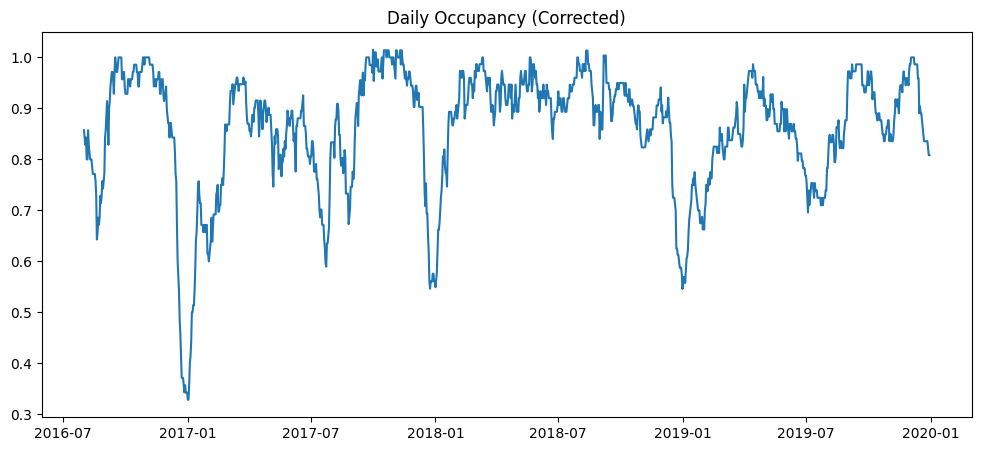

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily["Date"], daily["Occupancy"])
plt.title("Daily Occupancy (Corrected)")
plt.show()